<a href="https://colab.research.google.com/github/userskins/dsp-seminars-gusev-da/blob/Lab3/seminars/3_%D0%93%D1%83%D1%81%D0%B5%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

Theoretical sigma = 5.8310
MSE = 4.73621569e-17


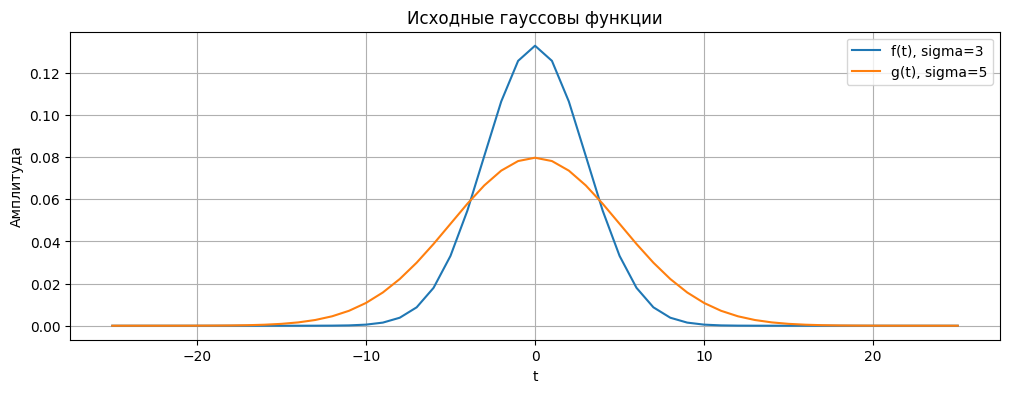

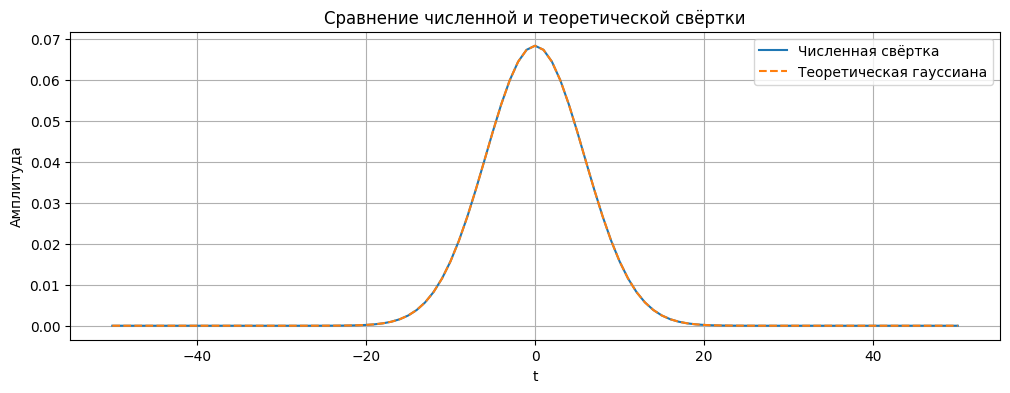

In [15]:
# Параметры
sigma1 = 3
sigma2 = 5
dt = 1.0

# Окно: достаточно длинное, чтобы захватить значимую часть гауссиан
M = int(10 * max(sigma1, sigma2))
if M % 2 == 0:
    M += 1

t = np.arange(-(M // 2), M // 2 + 1)

# Две гауссовы функции
f = (1 / (np.sqrt(2 * np.pi) * sigma1)) * np.exp(-t**2 / (2 * sigma1**2))
g = (1 / (np.sqrt(2 * np.pi) * sigma2)) * np.exp(-t**2 / (2 * sigma2**2))

# Численная свёртка
conv_num = np.convolve(f, g, mode='full') * dt
t_conv = np.arange(t[0] + t[0], t[-1] + t[-1] + dt, dt)

# Теоретический результат
sigma_th = np.sqrt(sigma1**2 + sigma2**2)
conv_th = (1 / (np.sqrt(2 * np.pi) * sigma_th)) * np.exp(-t_conv**2 / (2 * sigma_th**2))

# Ошибка
mse = np.mean((conv_num - conv_th)**2)

print(f"Theoretical sigma = {sigma_th:.4f}")
print(f"MSE = {mse:.8e}")

# Графики
plt.figure(figsize=(12, 4))
plt.plot(t, f, label='f(t), sigma=3')
plt.plot(t, g, label='g(t), sigma=5')
plt.title('Исходные гауссовы функции')
plt.xlabel('t')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_conv, conv_num, label='Численная свёртка')
plt.plot(t_conv, conv_th, '--', label='Теоретическая гауссиана')
plt.title('Сравнение численной и теоретической свёртки')
plt.xlabel('t')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()
plt.show()

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

**Ответ:** При увеличении σ свёртка остаётся гауссовой, но становится шире и более сглаженной, а её максимум уменьшается

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

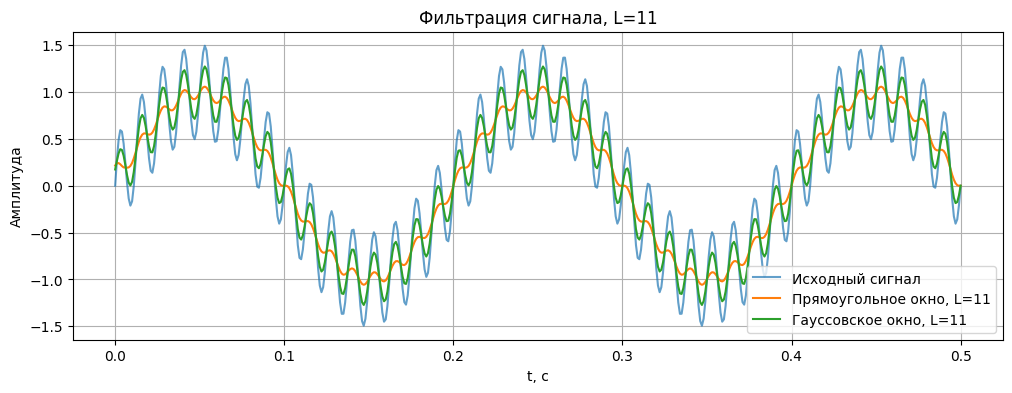

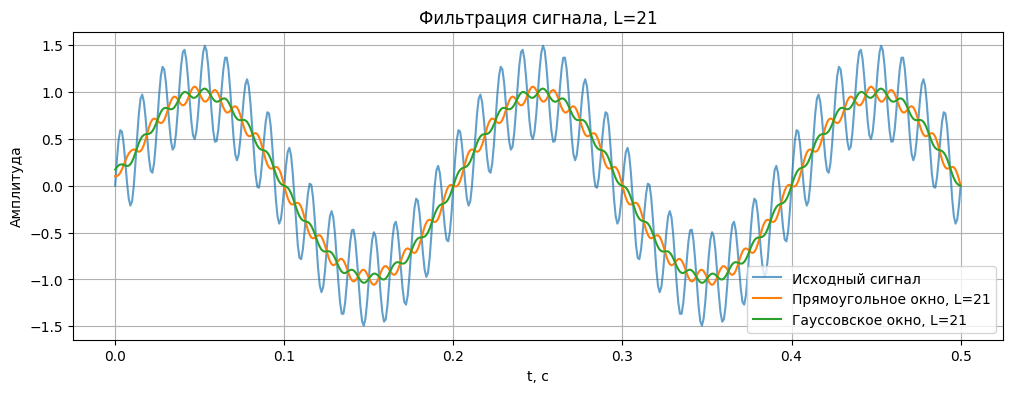

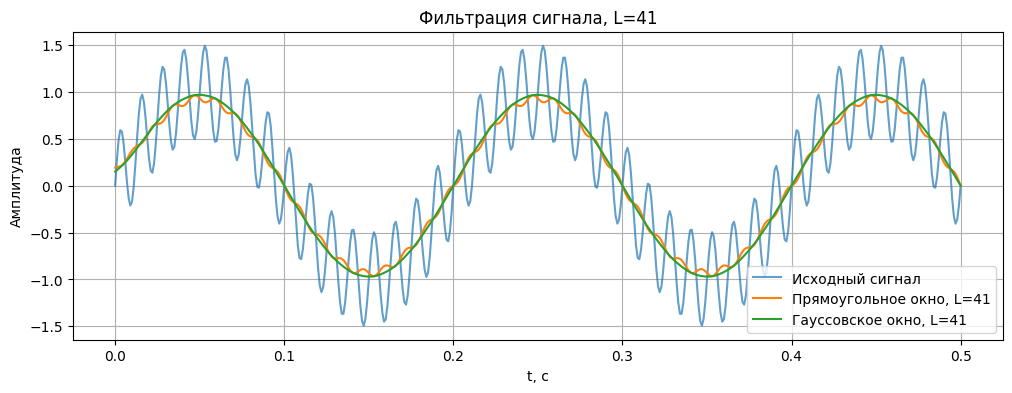

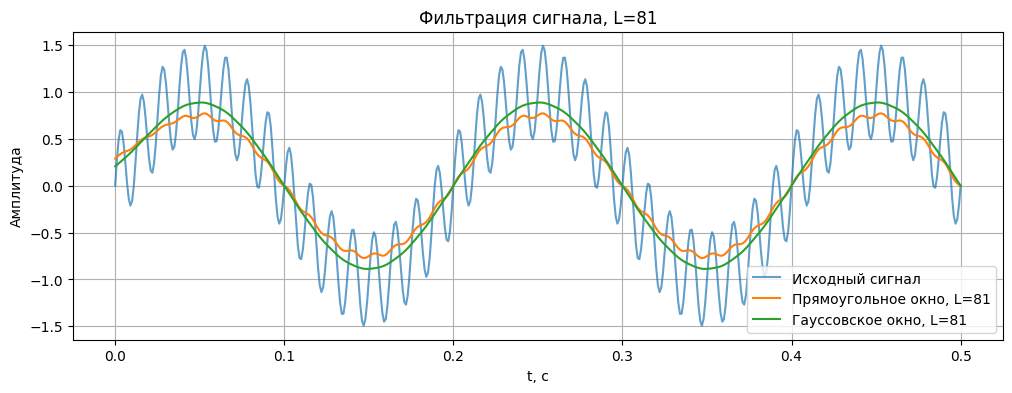

L | Rect(5 Hz) | Rect(80 Hz) | Gauss(5 Hz) | Gauss(80 Hz)
11 | 0.9951     | 0.0678      | 0.9978      | 0.2804
21 | 0.9822     | 0.0800      | 0.9922      | 0.0502
41 | 0.9330     | 0.0367      | 0.9704      | 0.0005
81 | 0.7542     | 0.0254      | 0.8891      | 0.0028


In [16]:
# Параметры
fs = 1000
T = 2.0
t = np.arange(0, T, 1/fs)

# Сигнал: 5 Гц + 80 Гц
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)

L_values = [11, 21, 41, 81]
results = []

for L in L_values:
    # Прямоугольное окно
    h_rect = signal.windows.boxcar(L)
    h_rect = h_rect / np.sum(h_rect)

    # Гауссовское окно
    h_gauss = signal.windows.gaussian(L, std=L/5)
    h_gauss = h_gauss / np.sum(h_gauss)

    # Фильтрация
    y_rect = np.convolve(x, h_rect, mode='same')
    y_gauss = np.convolve(x, h_gauss, mode='same')

    # БПФ
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    Y_rect = 2 * np.abs(np.fft.rfft(y_rect)) / len(x)
    Y_gauss = 2 * np.abs(np.fft.rfft(y_gauss)) / len(x)

    i5 = np.argmin(np.abs(freqs - 5))
    i80 = np.argmin(np.abs(freqs - 80))

    results.append({
        'L': L,
        'rect_5': Y_rect[i5],
        'rect_80': Y_rect[i80],
        'gauss_5': Y_gauss[i5],
        'gauss_80': Y_gauss[i80]
    })

    # Первые 0.5 с
    mask = t <= 0.5
    plt.figure(figsize=(12, 4))
    plt.plot(t[mask], x[mask], label='Исходный сигнал', alpha=0.7)
    plt.plot(t[mask], y_rect[mask], label=f'Прямоугольное окно, L={L}')
    plt.plot(t[mask], y_gauss[mask], label=f'Гауссовское окно, L={L}')
    plt.title(f'Фильтрация сигнала, L={L}')
    plt.xlabel('t, c')
    plt.ylabel('Амплитуда')
    plt.grid()
    plt.legend()
    plt.show()

print("L | Rect(5 Hz) | Rect(80 Hz) | Gauss(5 Hz) | Gauss(80 Hz)")
for r in results:
    print(f"{r['L']:2d} | {r['rect_5']:.4f}     | {r['rect_80']:.4f}      | {r['gauss_5']:.4f}      | {r['gauss_80']:.4f}")

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

**Ответы:**
- При одинаковой длине окна прямоугольное окно лучше подавляет высокую частоту 80 Гц, чем гауссовское.
- Падение амплитуды 80 Гц в 10 раз в рассмотренных длинах достигается только для прямоугольного окна при `L = 21` для гауссовского окна даже при `L = 81` амплитуда остаётся больше 0.05 от исходной.
- При увеличении длины окна подавление высокой частоты усиливается, но сильнее ослабляется и низкочастотная составляющая 5 Гц. Более чем на 10% амплитуда 5 Гц уменьшается при `L = 81` для обоих окон.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

noise_level | estimated_delay | error
       0.0 |             100 |     0
       0.2 |             100 |     0
       0.4 |             100 |     0
       0.6 |             100 |     0
       0.8 |             100 |     0
       1.0 |             100 |     0
       1.2 |             100 |     0
       1.4 |              99 |     1
       1.6 |              99 |     1
       1.8 |              99 |     1
       2.0 |              99 |     1


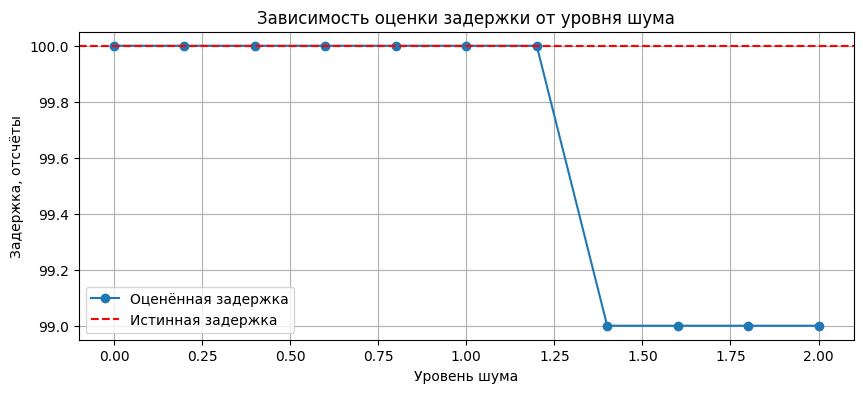

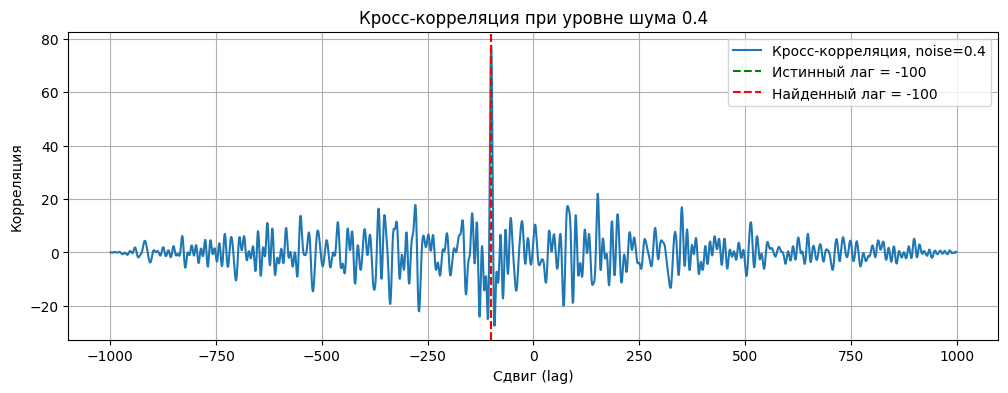

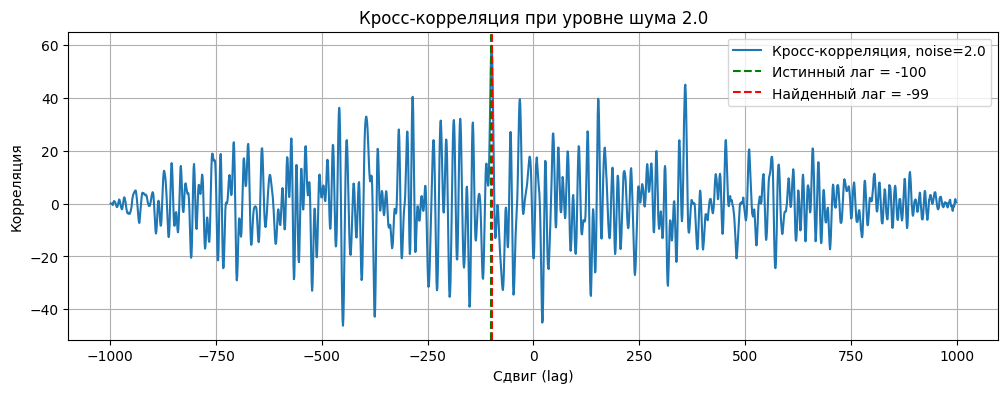

In [20]:
np.random.seed(42)

# Параметры
fs = 1000
T = 1.0
N = int(fs * T)
t = np.arange(N) / fs

true_delay = 100
noise_levels = np.linspace(0, 2, 11)

# Сигнал x: сумма 100 синусоид
x = np.zeros(N)
for _ in range(100):
    f = np.random.uniform(10, 100)
    A = np.random.uniform(0.5, 1.5)
    phi = np.random.uniform(0, 2*np.pi)
    x += A * np.sin(2 * np.pi * f * t + phi)

x = x / np.max(np.abs(x))

estimated_delays = []
saved_corrs = {}

for noise_level in noise_levels:
    y = np.roll(x, true_delay) + noise_level * np.random.randn(N)

    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-N + 1, N)

    lag_at_max = lags[np.argmax(corr)]
    estimated_delay = abs(lag_at_max)   # оцениваем величину задержки

    estimated_delays.append(estimated_delay)

    if np.isclose(noise_level, 0.4) or np.isclose(noise_level, 2.0):
        saved_corrs[noise_level] = (lags, corr, lag_at_max)

print("noise_level | estimated_delay | error")
for nl, est in zip(noise_levels, estimated_delays):
    print(f"{nl:10.1f} | {est:15d} | {abs(est - true_delay):5d}")

plt.figure(figsize=(10, 4))
plt.plot(noise_levels, estimated_delays, 'o-', label='Оценённая задержка')
plt.axhline(true_delay, color='r', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Задержка, отсчёты')
plt.title('Зависимость оценки задержки от уровня шума')
plt.grid()
plt.legend()
plt.show()

for nl in [0.4, 2.0]:
    lags, corr, lag_at_max = saved_corrs[nl]
    plt.figure(figsize=(12, 4))
    plt.plot(lags, corr, label=f'Кросс-корреляция, noise={nl}')
    plt.axvline(-true_delay, color='g', linestyle='--', label='Истинный лаг = -100')
    plt.axvline(lag_at_max, color='r', linestyle='--', label=f'Найденный лаг = {lag_at_max}')
    plt.xlabel('Сдвиг (lag)')
    plt.ylabel('Корреляция')
    plt.title(f'Кросс-корреляция при уровне шума {nl}')
    plt.grid()
    plt.legend()
    plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

**Ответы:**
- Точность в этом эксперименте почти не меняется с ростом шума: оценка задержки остаётся около `100` отсчётов, что соответствует истинной задержке `100` отсчётов по модулю, но с противоположным знаком из-за порядка сигналов в корреляции. Отклонение более чем на `10%` не наблюдается во всём исследованном диапазоне шума. Практически неотличимой от `0` задержка не становится.
- При высоком шуме шумовые компоненты создают случайные совпадения между сигналами, поэтому в кросс-корреляции возникают дополнительные локальные максимумы. Из-за этого главный пик может сместиться от истинной задержки.

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

A (SNR) | true_pos | detected_pos | error
  0.20 |      413 |          409 |     4
  0.60 |      731 |          732 |     1
  1.00 |      819 |          820 |     1
  1.40 |      818 |          817 |     1
  1.80 |      982 |          982 |     0
  2.20 |       41 |           41 |     0
  2.60 |      551 |          551 |     0
  3.00 |      465 |          465 |     0
  3.40 |      721 |          721 |     0
  3.80 |     1299 |         1299 |     0
  4.20 |      824 |          824 |     0
  4.60 |     1243 |         1243 |     0
  5.00 |       71 |           71 |     0


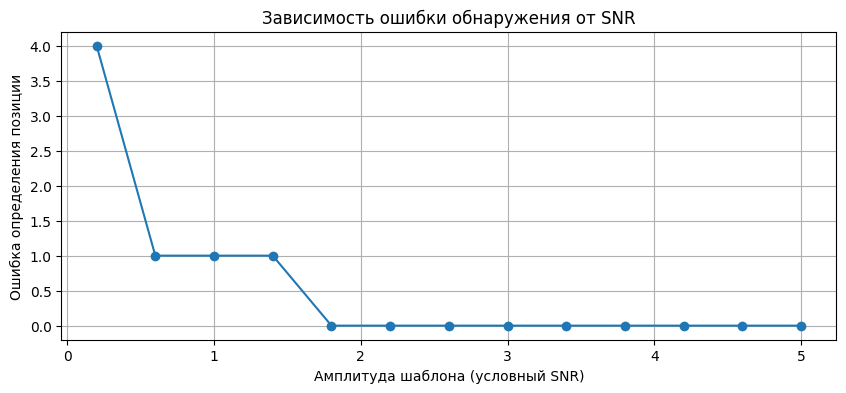

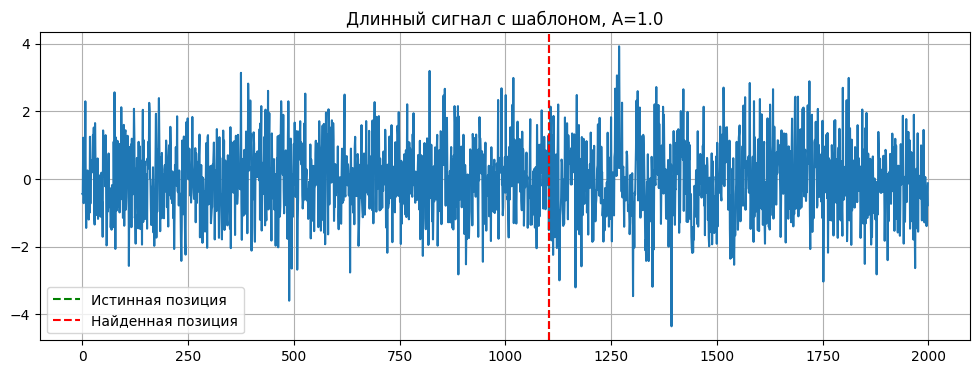

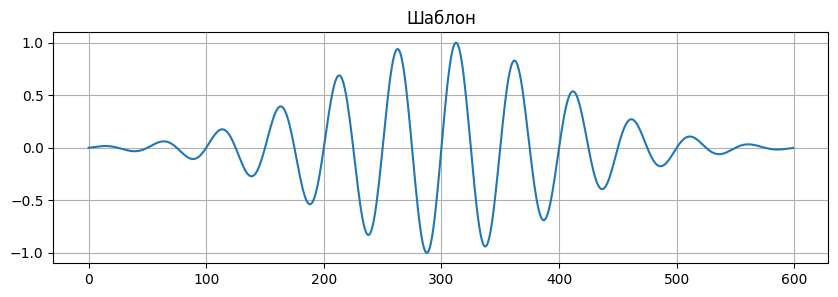

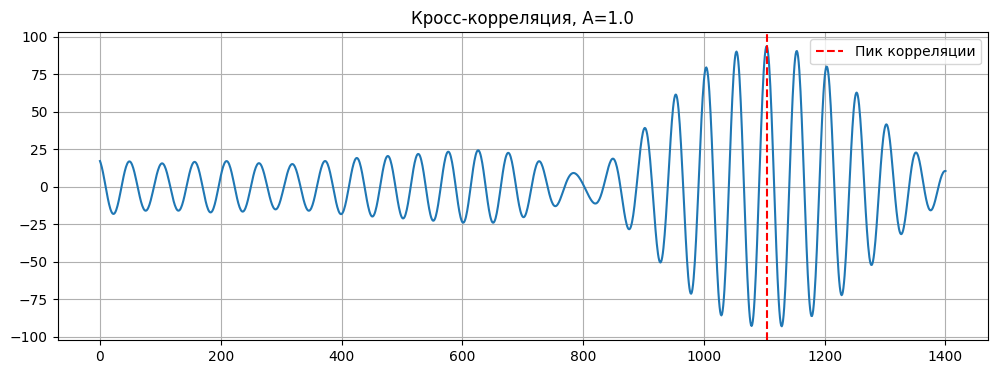

In [22]:
np.random.seed(42)

# Параметры
fs = 1000
N = 2000

# Шаблон
template_len = 600
tt = np.arange(template_len)
center = template_len // 2
sigma = 100
f0 = 20

gauss_env = np.exp(-((tt - center) ** 2) / (2 * sigma**2))
template = gauss_env * np.sin(2 * np.pi * f0 * tt / fs)

# Нормируем шаблон
template = template / np.max(np.abs(template))

A_values = np.arange(0.2, 5.1, 0.4)

true_positions = []
detected_positions = []
errors = []

for A in A_values:
    long_signal = np.random.randn(N)

    pos = np.random.randint(0, N - template_len)
    long_signal[pos:pos + template_len] += A * template

    corr = np.correlate(long_signal, template, mode='valid')
    detected_pos = np.argmax(corr)

    true_positions.append(pos)
    detected_positions.append(detected_pos)
    errors.append(abs(detected_pos - pos))

print("A (SNR) | true_pos | detected_pos | error")
for A, p_true, p_det, err in zip(A_values, true_positions, detected_positions, errors):
    print(f"{A:6.2f} | {p_true:8d} | {p_det:12d} | {err:5d}")

plt.figure(figsize=(10, 4))
plt.plot(A_values, errors, 'o-')
plt.xlabel('Амплитуда шаблона (условный SNR)')
plt.ylabel('Ошибка определения позиции')
plt.title('Зависимость ошибки обнаружения от SNR')
plt.grid()
plt.show()

# Визуализация для A = 1.0
A_vis = 1.0
long_signal = np.random.randn(N)
pos = np.random.randint(0, N - template_len)
long_signal[pos:pos + template_len] += A_vis * template

corr = np.correlate(long_signal, template, mode='valid')
detected_pos = np.argmax(corr)

plt.figure(figsize=(12, 4))
plt.plot(long_signal)
plt.axvline(pos, color='g', linestyle='--', label='Истинная позиция')
plt.axvline(detected_pos, color='r', linestyle='--', label='Найденная позиция')
plt.title(f'Длинный сигнал с шаблоном, A={A_vis}')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(template)
plt.title('Шаблон')
plt.grid()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(corr)
plt.axvline(detected_pos, color='r', linestyle='--', label='Пик корреляции')
plt.title(f'Кросс-корреляция, A={A_vis}')
plt.legend()
plt.grid()
plt.show()

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

**Ответ:** Результаты измерения резко ухудшаются при низком SNR, примерно, при `SNR <= 1`. По полученным данным большие ошибки наблюдаются при `A = 0.2` и `A = 1.0`, тогда как начиная примерно с `A >= 1.4` обнаружение становится устойчивым, и ошибка почти исчезает.


## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [23]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-12 20:38:43--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-12 20:38:44--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6990446 (6.7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6.67M  --.-KB/s    in 0.08s   

2026-04-12 20:38:44 (85.3 MB/s) - ‘full_audio.wav’ saved [6990446/6

/tmp/ipykernel_1482/2854676956.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full_audio = wavfile.read("full_audio.wav")
/tmp/ipykernel_1482/2854676956.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, fragment = wavfile.read("fragment.wav")


Позиция фрагмента: 279235 отсчётов
Время смещения: 6.3319 с


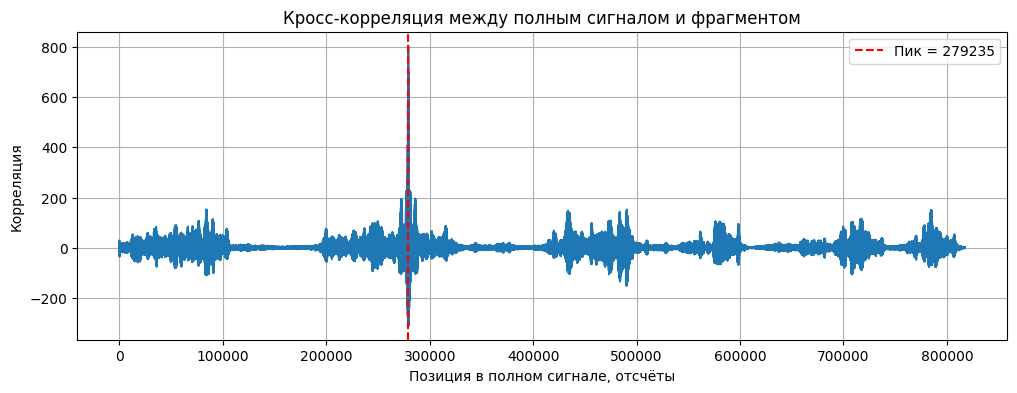

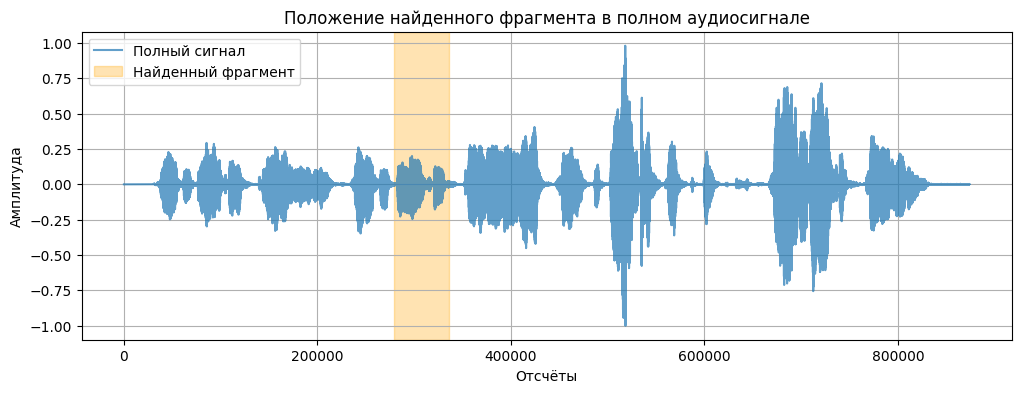

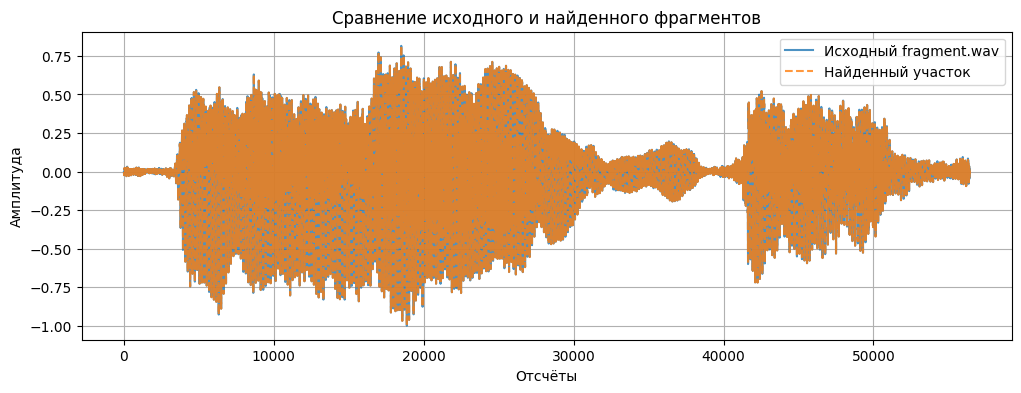

fragment.wav:


Найденный участок из full_audio.wav:


In [24]:
# Чтение файлов
fs_full, full_audio = wavfile.read("full_audio.wav")
fs_frag, fragment = wavfile.read("fragment.wav")

if fs_full != fs_frag:
    raise ValueError("Частоты дискретизации не совпадают")

fs = fs_full

# В float
full_audio = full_audio.astype(np.float64)
fragment = fragment.astype(np.float64)

# Если стерео -> моно
if full_audio.ndim > 1:
    full_audio = full_audio.mean(axis=1)
if fragment.ndim > 1:
    fragment = fragment.mean(axis=1)

# Нормализация в [-1, 1]
full_audio = full_audio / np.max(np.abs(full_audio))
fragment = fragment / np.max(np.abs(fragment))

# Убираем среднее
full_audio_zm = full_audio - np.mean(full_audio)
fragment_zm = fragment - np.mean(fragment)

# Кросс-корреляция
corr = np.correlate(full_audio_zm, fragment_zm, mode='valid')

peak_idx = np.argmax(corr)
peak_time = peak_idx / fs

print(f"Позиция фрагмента: {peak_idx} отсчётов")
print(f"Время смещения: {peak_time:.4f} с")

# График корреляции
plt.figure(figsize=(12, 4))
plt.plot(corr)
plt.axvline(peak_idx, color='r', linestyle='--', label=f'Пик = {peak_idx}')
plt.title('Кросс-корреляция между полным сигналом и фрагментом')
plt.xlabel('Позиция в полном сигнале, отсчёты')
plt.ylabel('Корреляция')
plt.grid()
plt.legend()
plt.show()

# Положение фрагмента
plt.figure(figsize=(12, 4))
plt.plot(full_audio, alpha=0.7, label='Полный сигнал')
plt.axvspan(peak_idx, peak_idx + len(fragment), color='orange', alpha=0.3, label='Найденный фрагмент')
plt.title('Положение найденного фрагмента в полном аудиосигнале')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()
plt.show()

# Найденный участок
found_fragment = full_audio[peak_idx:peak_idx + len(fragment)]

# Для сравнения тоже нормируем отдельно
found_fragment_norm = found_fragment / np.max(np.abs(found_fragment))
fragment_norm = fragment / np.max(np.abs(fragment))

plt.figure(figsize=(12, 4))
plt.plot(fragment_norm, label='Исходный fragment.wav', alpha=0.8)
plt.plot(found_fragment_norm, '--', label='Найденный участок', alpha=0.8)
plt.title('Сравнение исходного и найденного фрагментов')
plt.xlabel('Отсчёты')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()
plt.show()

print("fragment.wav:")
display(Audio(fragment_norm, rate=fs))

print("Найденный участок из full_audio.wav:")
display(Audio(found_fragment_norm, rate=fs))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

**Ответы:**
- Нормализация нужна, чтобы корреляция зависела прежде всего от сходства формы сигнала, а не от его громкости. Без нормализации более амплитудные участки могли бы давать завышенные пики.
- По данному результату надёжно обнаружено одно наиболее выраженное вхождение фрагмента — в позиции `279235` отсчётов (`6.3319 с`). По одному графику корреляции нельзя уверенно утверждать, что других вхождений нет совсем, но явного второго пика такого же уровня не видно. Корреляционный анализ позволяет находить похожие участки, однако при наличии шума и похожих по форме фрагментов могут возникать ложные локальные максимумы.
- Если фрагмента в полном сигнале нет, то чёткого доминирующего пика корреляции не будет. Вместо него останутся только сравнительно небольшие случайные локальные максимумы, и надёжно определить позицию совпадения не получится.